# Lung Data (He et al., 2022)

He, S. et al. High-plex imaging of RNA and proteins at subcellular resolution in fixed tissue by spatial molecular imaging. Nat Biotechnol 40, 1794–1806 (2022).

In [1]:
import scanpy as sc
import numpy as np
import squidpy as sq

/home/icb/francesca.drummer/miniconda3/envs/exphormer_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

In [3]:
HE22_HUMAN_LUNG_DATA_PATH = '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/unprocessed_data/he22_cosmx_human_lung.h5ad'

In [4]:
adata = sc.read_h5ad(HE22_HUMAN_LUNG_DATA_PATH)
adata

AnnData object with n_obs × n_vars = 771236 × 960
    obs: 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'niche', 'image_id', 'cell_ID', 'sex_ontology_term_id', 'assay_ontology_term_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'tissue_type', 'condition_id', 'sample_id', 'donor_id', 'author_cell_type', 'library_key', 'region', 'assay', 'organism', 'sex', 'tissue', 'dataset', 'x', 'y', 'nicheformer_split', '_scvi_batch', '_scvi_labels', 'split'
    var: 'level_0', 'index', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'niche', 'nicheformer_version', 'schema_version', 'title'
    obsm: 'X_niche_0', 'X_niche_1', 'X_niche_2', 'X_niche_3', 'X_niche_4', 'X_pca', 'X_scvi', 'spatial'
    layers: 'log1p', '

In [6]:
niche_array = np.unique(adata.obs['niche'])
print(f'Number of niches: ', len(niche_array))
print(niche_array)

Number of niches:  9
['immune' 'lymphoid structure' 'macrophages' 'myeloid-enriched stroma'
 'neutrophils' 'plasmablast-enriched stroma' 'stroma' 'tumor interior'
 'tumor-stroma boundary']


In [7]:
cell_type_array = np.unique(adata.obs['author_cell_type'])
print(f'Number of cell types: ', len(cell_type_array))
print(cell_type_array)

Number of cell types:  22
['B-cell' 'NK' 'T CD4 memory' 'T CD4 naive' 'T CD8 memory' 'T CD8 naive'
 'Treg' 'endothelial' 'epithelial' 'fibroblast' 'mDC' 'macrophage' 'mast'
 'monocyte' 'neutrophil' 'pDC' 'plasmablast' 'tumor 12' 'tumor 13'
 'tumor 5' 'tumor 6' 'tumor 9']


## Visualization

/home/icb/francesca.drummer/miniconda3/envs/exphormer_env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/icb/francesca.drummer/miniconda3/envs/exphormer_env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/icb/francesca.drummer/miniconda3/envs/exphormer_env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value t

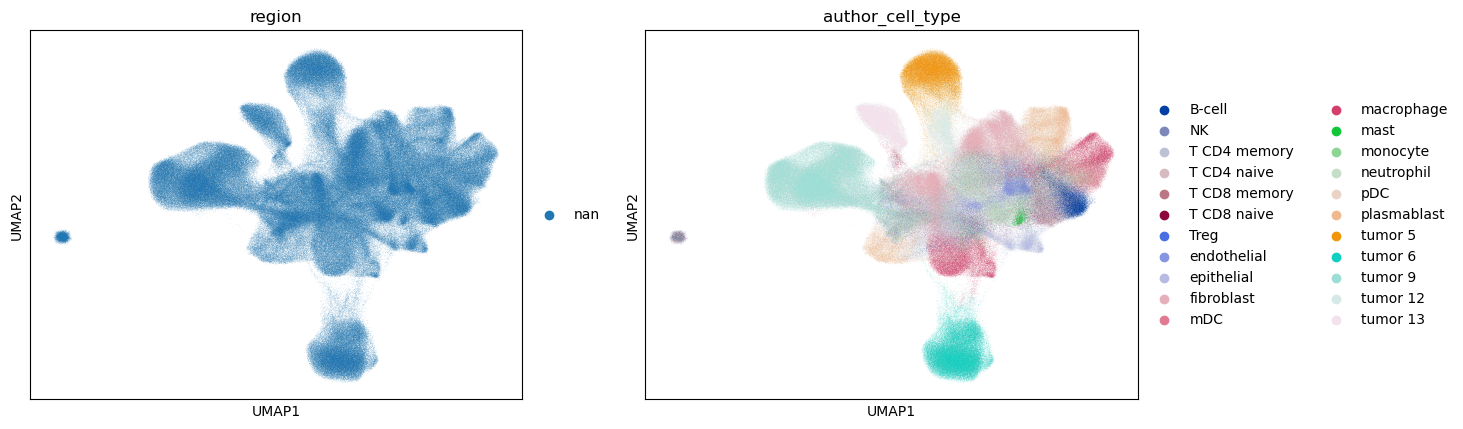

In [10]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

/home/icb/francesca.drummer/miniconda3/envs/exphormer_env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/icb/francesca.drummer/miniconda3/envs/exphormer_env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


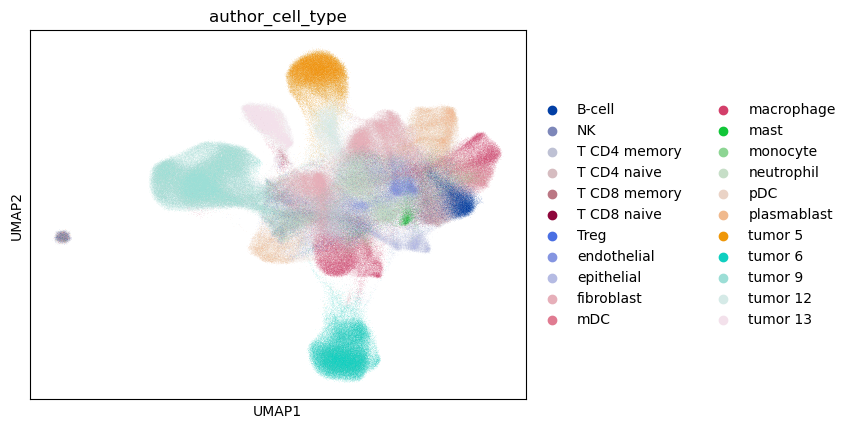

In [12]:
sc.pl.umap(adata, color = ["author_cell_type"])

## Spatial Graph

How  many k-hops for 2k-3k big graphs?

In [53]:
max_coords_x = adata.obs.groupby('library_key')[['x']].max()
min_coords_x = adata.obs.groupby('library_key')[['x']].min()    
max_coords_y = adata.obs.groupby('library_key')[['y']].max()
min_coords_y = adata.obs.groupby('library_key')[['y']].min()  

/tmp/ipykernel_3575897/2449458805.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_coords_x = adata.obs.groupby('library_key')[['x']].max()
/tmp/ipykernel_3575897/2449458805.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  min_coords_x = adata.obs.groupby('library_key')[['x']].min()
/tmp/ipykernel_3575897/2449458805.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_coords_y = adata.obs.groupby('library_ke

In [54]:
x_diff = max_coords_x - min_coords_x
y_diff = max_coords_y - min_coords_y
x_diff, y_diff

(                        x
 library_key              
 0            27337.888889
 1            27344.888889
 2            27336.888889
 3            27337.888889
 4            21864.666667
 5            27333.888889
 6            21869.666667
 7            21863.666667,
                    y
 library_key         
 0            21877.0
 1            21878.0
 2            21875.0
 3            21877.0
 4            18223.0
 5            32822.0
 6            25525.0
 7            18228.0)

In [55]:
NR_CELLS_PER_WINDOW = 2000
cell_count_per_fov = adata.obs.groupby('library_key').size()
cell_count_per_fov

/tmp/ipykernel_3575897/3078604022.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_count_per_fov = adata.obs.groupby('library_key').size()


library_key
0     98002
1    105800
2     97809
3     89975
4     87606
5    139504
6     71304
7     81236
dtype: int64

In [56]:
windows_per_image = np.ceil(np.divide(cell_count_per_fov, NR_CELLS_PER_WINDOW))
windows_per_image

library_key
0    50.0
1    53.0
2    49.0
3    45.0
4    44.0
5    70.0
6    36.0
7    41.0
dtype: float64

In [57]:
rows = np.ceil(np.sqrt(windows_per_image))
cols = np.ceil(np.divide(windows_per_image, rows))
rows, cols


(library_key
 0    8.0
 1    8.0
 2    7.0
 3    7.0
 4    7.0
 5    9.0
 6    6.0
 7    7.0
 dtype: float64,
 library_key
 0    7.0
 1    7.0
 2    7.0
 3    7.0
 4    7.0
 5    8.0
 6    6.0
 7    6.0
 dtype: float64)

In [58]:
x_diff['x'][0]

27337.88888888891

In [59]:
x_size = x_diff / rows
y_size = np.divide(y_diff, cols)
x_size, y_size

(              x   0   1   2   3   4   5   6   7
 library_key                                    
 0           NaN NaN NaN NaN NaN NaN NaN NaN NaN
 1           NaN NaN NaN NaN NaN NaN NaN NaN NaN
 2           NaN NaN NaN NaN NaN NaN NaN NaN NaN
 3           NaN NaN NaN NaN NaN NaN NaN NaN NaN
 4           NaN NaN NaN NaN NaN NaN NaN NaN NaN
 5           NaN NaN NaN NaN NaN NaN NaN NaN NaN
 6           NaN NaN NaN NaN NaN NaN NaN NaN NaN
 7           NaN NaN NaN NaN NaN NaN NaN NaN NaN,
               y   0   1   2   3   4   5   6   7
 library_key                                    
 0           NaN NaN NaN NaN NaN NaN NaN NaN NaN
 1           NaN NaN NaN NaN NaN NaN NaN NaN NaN
 2           NaN NaN NaN NaN NaN NaN NaN NaN NaN
 3           NaN NaN NaN NaN NaN NaN NaN NaN NaN
 4           NaN NaN NaN NaN NaN NaN NaN NaN NaN
 5           NaN NaN NaN NaN NaN NaN NaN NaN NaN
 6           NaN NaN NaN NaN NaN NaN NaN NaN NaN
 7           NaN NaN NaN NaN NaN NaN NaN NaN NaN)

In [61]:
adata.obs['window'] = None
for image in np.unique(adata.obs['library_key']):
    x_size = x_diff['x'][image] / rows[image]
    y_size = y_diff['y'][image] / cols[image]
    for row in range(int(rows[image])):
        for col in range(int(cols[image])): 
            x_min = min_coords_x['x'][image] + x_size * row
            x_max = min_coords_x['x'][image]  + x_size * (row + 1)
            y_min = min_coords_y['y'][image]  + y_size * col
            y_max = min_coords_y['y'][image] + y_size * (col + 1)
            selected_cells = (adata.obs['x'] > x_min) & (adata.obs['x'] < x_max) & (adata.obs['y'] > y_min) & (adata.obs['y'] < y_max)
            # Update the values of selected cells to 0
            adata.obs.loc[selected_cells, 'window'] = f'{image}_{row}_{col}'

In [69]:
cells_per_window = adata.obs.groupby('window').size()
print(cells_per_window.max(), cells_per_window.min(), cells_per_window.mean(), len(cells_per_window))

4874 254 2056.541333333333 375


/tmp/ipykernel_3575897/3178517769.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cells_per_window = adata.obs.groupby('window').size()


In [67]:
adata.write(HE22_HUMAN_LUNG_DATA_PATH)

In [16]:
sq.gr.spatial_neighbors(adata=adata, radius=30, key_added="adjacency_matrix", coord_type="generic")